In [2]:
import Pkg
using Sunny, GLMakie, StaticArrays, LinearAlgebra

In [3]:
units = Units(:meV, :angstrom);

In [3]:
latvecs = lattice_vectors(7.3177, 7.3177, 17.534, 90, 90, 120)
fe_cryst = Crystal(latvecs, [[1/6, 5/6, 5/6]], 166)

# cryst = Crystal("ammoniojarosite.cif")
# fe_cryst = subcrystal(cryst, "Fe")
moments = [1 => Moment(s=5/2, g=2)]  
sys = System(fe_cryst, moments, :dipole; dims=(18,18,12))

D = [0, 0.218, -0.195]
set_exchange!(sys, 3.3*Matrix(I, 3, 3) + dmvec(D), Bond(1, 2, [0, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [1, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [0, 1, 0]))

In [4]:
#randomize_spins!(sys)
minimize_energy!(sys)
#display(plot_spins(sys; color=[S[3] for S in sys.dipoles]))

Converged in 60 iterations

In [ ]:
qs1 = [[0, 0, 0], [1/3, 1/3, 0], [1/2, 0, 0], [0, 0, 0]]
qs2 = [[0, 0, 2], [1/3, 1/3, 2], [1/2, 0, 2], [0, 0, 2]]
qs3 = [[0, 0, 4], [1/3, 1/3, 4], [1/2, 0, 4], [0, 0, 4]]
labels = ["Γ", "X", "Y", "Γ"]
path1 = q_space_path(fe_cryst, qs1, 150; labels)
path2 = q_space_path(fe_cryst, qs2, 150; labels)
path3 = q_space_path(fe_cryst, qs3, 150; labels)

kernel = lorentzian(fwhm=0.2)
energies = range(0, 25, 150)

0.0:0.16778523489932887:25.0

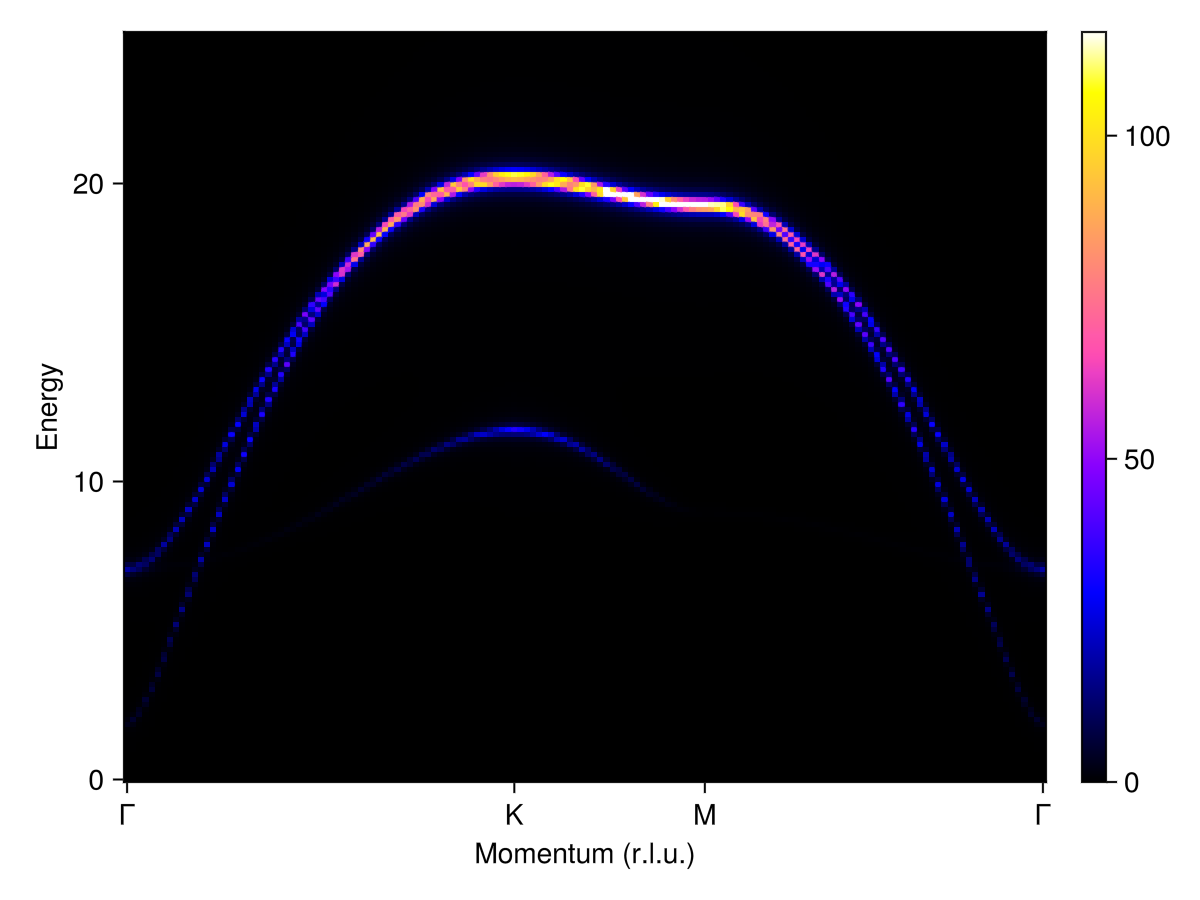

In [9]:
swt = SpinWaveTheory(sys; measure=ssf_perp(sys))
res1 = intensities(swt, path1; energies, kernel)
plot_intensities(res1)

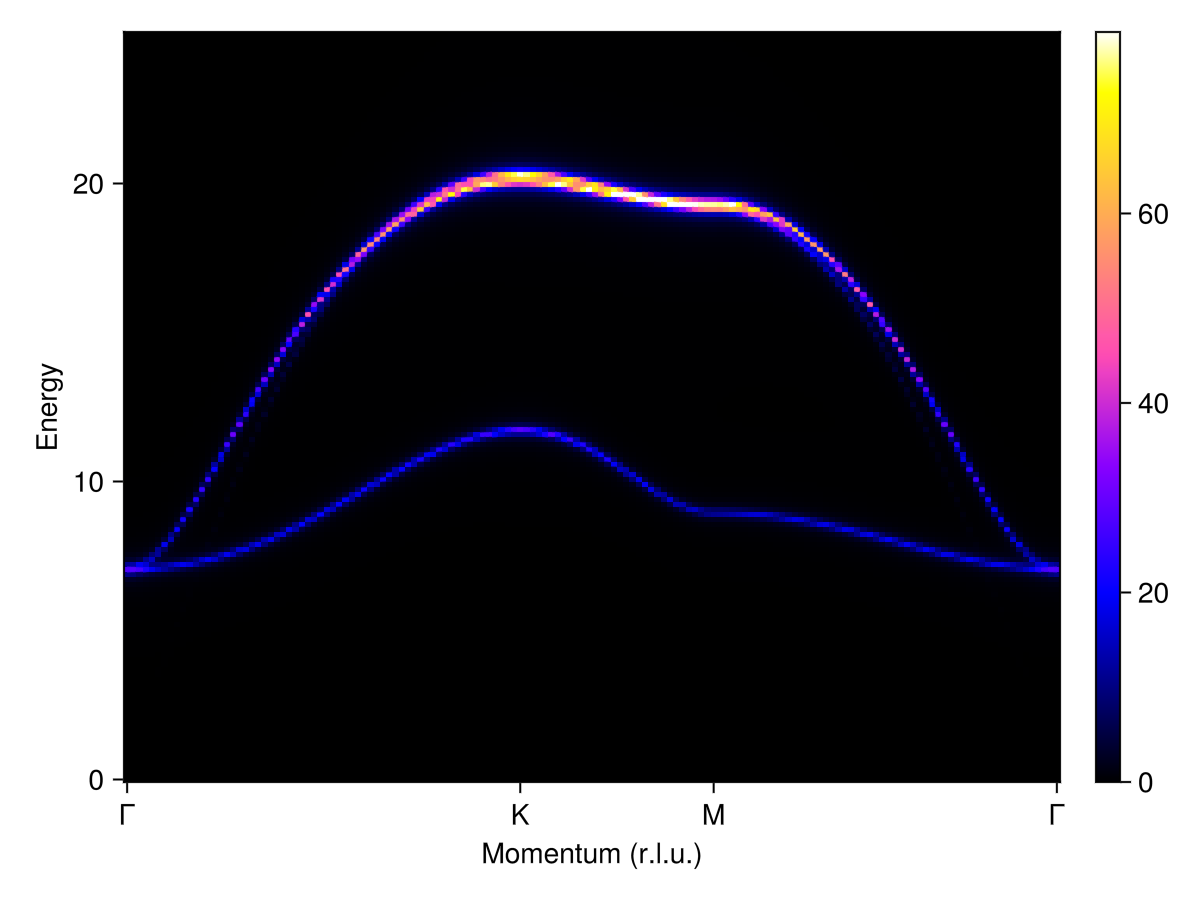

In [15]:
res2 = intensities(swt, path2; energies, kernel)
plot_intensities(res2)

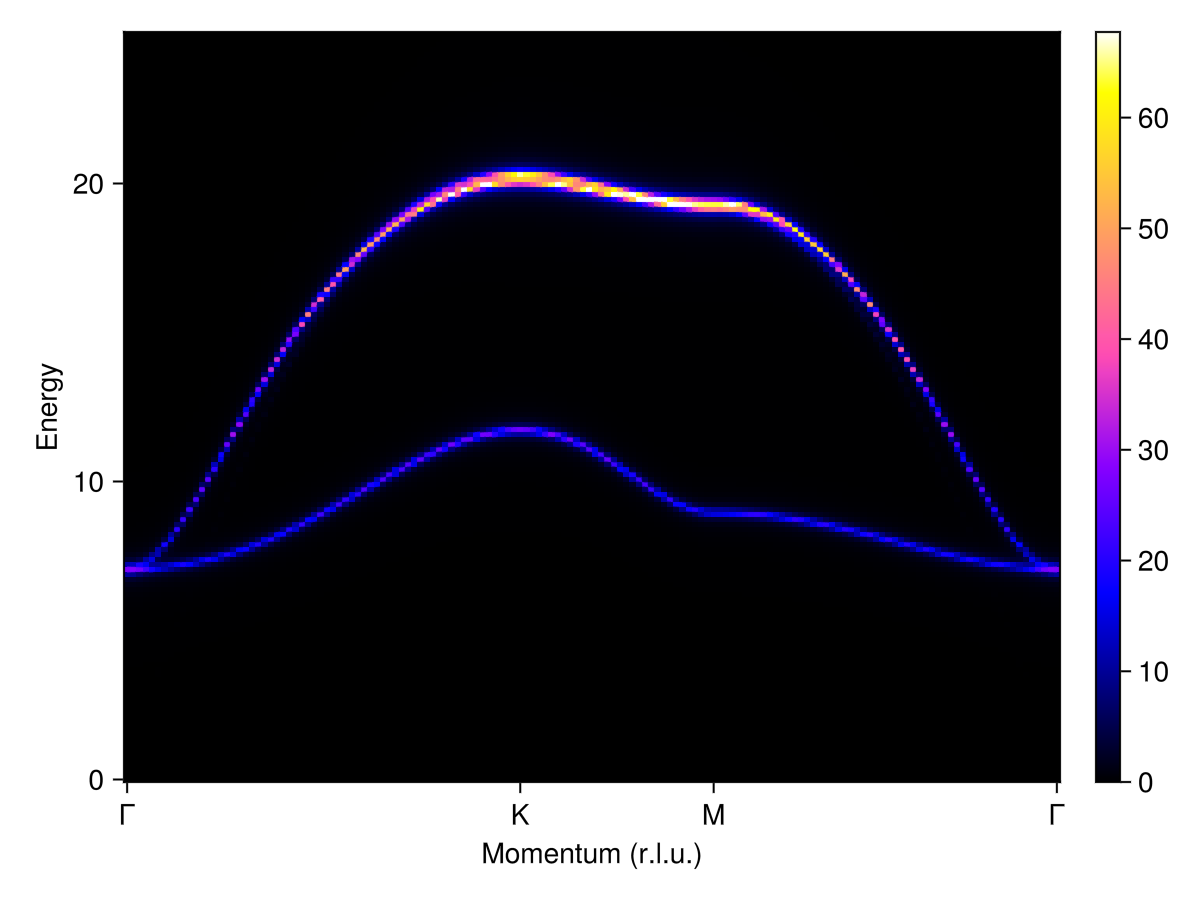

In [14]:
res3 = intensities(swt, path3; energies, kernel)
plot_intensities(res3)

In [ ]:
# res_data = (res1.data + res2.data + res3.data)/3
# res_e = (res1.energies + res2.energies + res3.energies)/3

# filepath = joinpath(@__DIR__, "resdata.txt")
# filepath2 = joinpath(@__DIR__, "resE.txt")
# open(filepath, "w") do f
#     for row in eachrow(res_data)
#         println(f, join(row, ", "))
#     end
# end
# open(filepath2, "w") do f
#     for row in eachrow(res_e)
#         println(f, join(row, ", "))
#     end
# end

In [61]:
# Tager nok 6ish timer, kør forsigtigt 
#Remember to thermalize for 10,000 at the start temperature in the cell below !! 

for T in range(57.5, 70, 26)
    langevin = Langevin(; damping = 0.15, kT = T*units.K)
    langevin.dt = 0.004
    energies = [energy_per_site(sys)]
    for _ in 1:1000 # start by thermalizing the system at each T 
        step!(sys, langevin)
    end
    for _ in 1:100
        for _ in 1:100
            step!(sys, langevin)
        end
        push!(energies, energy_per_site(sys))
    end
    filepath = joinpath(@__DIR__, "E$(Int(T*10)).txt")
    open(filepath, "w") do f
        for row in eachrow(energies)
            println(f, join(row, ", "))
        end
    end    
end

# Langevin 

In [102]:
langevin = Langevin(; damping=0.1, kT=200*units.K)
suggest_timestep(sys, langevin; tol=1e-2)
langevin.dt = 0.004726;

Consider dt ≈ 0.005997 for this spin configuration at tol = 0.01000.


In [103]:
energies = [energy_per_site(sys)]
for _ in 1:10000
    step!(sys, langevin)
    push!(energies, energy_per_site(sys))
end

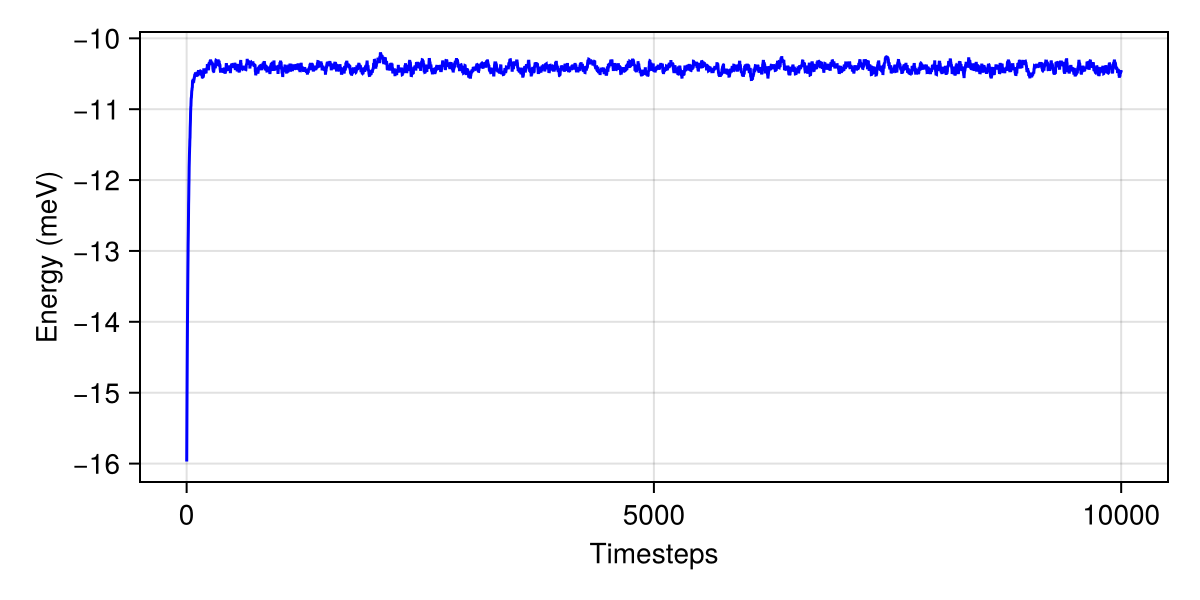

In [104]:
lines(energies, color=:blue, figure=(size=(600,300),), axis=(xlabel="Timesteps", ylabel="Energy (meV)"))

In [95]:
# filepath = joinpath(@__DIR__, "energies ##K.txt")
# open(filepath, "w") do f
#     for row in eachrow(energies)
#         println(f, join(row, ", "))
#     end
# end

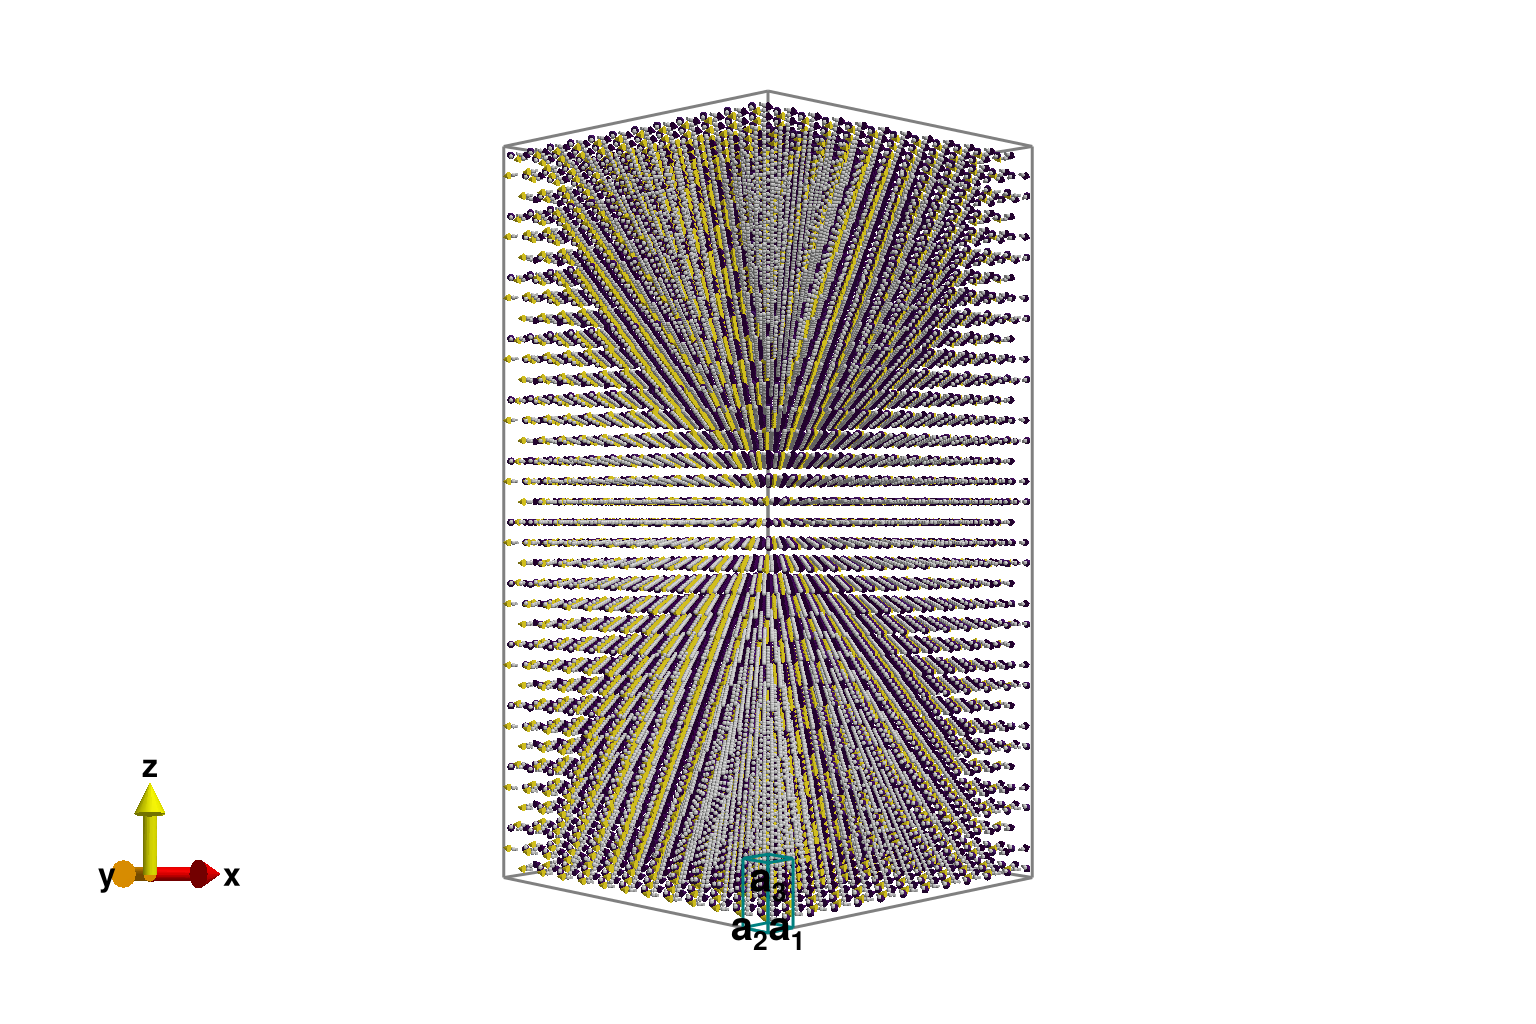

CairoMakie.Screen{IMAGE}


In [44]:
S0 = sys.dipoles[1,1,1,1]
display(plot_spins(sys; color=[S'*S0 for S in sys.dipoles]))

In [87]:
formfactors = [1 => FormFactor("Fe3")]
measure = ssf_perp(sys; formfactors)
sc = SampledCorrelationsStatic(sys; measure)
add_sample!(sc, sys)

In [88]:
for _ in 1:40
    for _ in 1:100 #måske mere her
        step!(sys, langevin)
    end
    add_sample!(sc, sys)
end

In [70]:
grid = q_space_grid(
    fe_cryst,
    [1, 0, 0], range(-4, 4, 1000),
    [0, 1, 0], range(-4, 4, 1000), offset = [0,0,0], orthogonalize=true
)

# grid = q_space_grid(
#     fe_cryst,
#     [1, 0, 0], range(-2, 2, 1000),
#     [0, 0, 1], range(-5, 5, 1000), offset = [0,0,0], orthogonalize=true
# )

Sunny.QGrid{2} (1000×1000 samples)

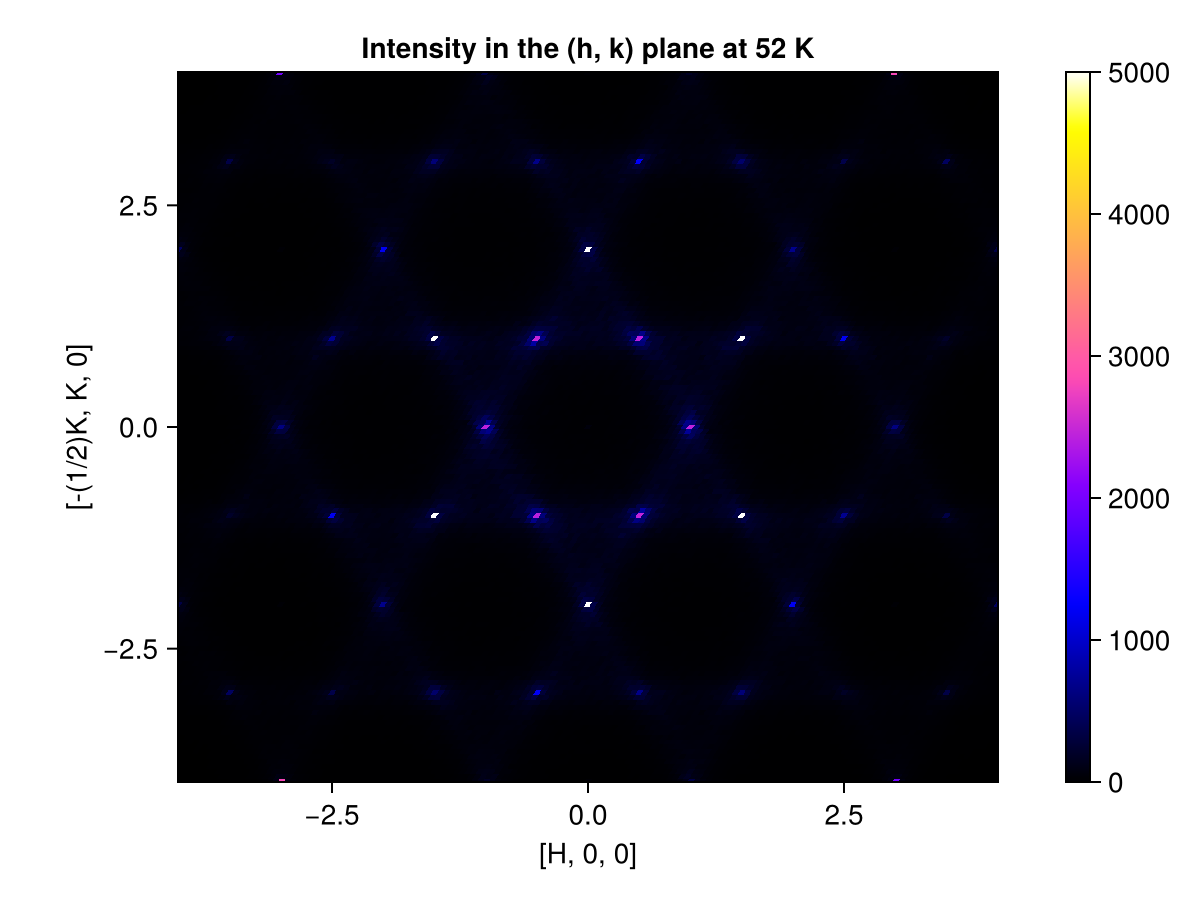

In [75]:
res = intensities_static(sc, grid)
using CairoMakie
plot_intensities(res, colorrange=(0, 5000), title="Intensity in the (h, k) plane at 52 K")

In [105]:
path = q_space_path(
    fe_cryst,
    [[-2, 0, 0], [2, 0, 0]],
    150; labels=["Γ", "Γ"])

QPath (150 samples)
  Γ → Γ


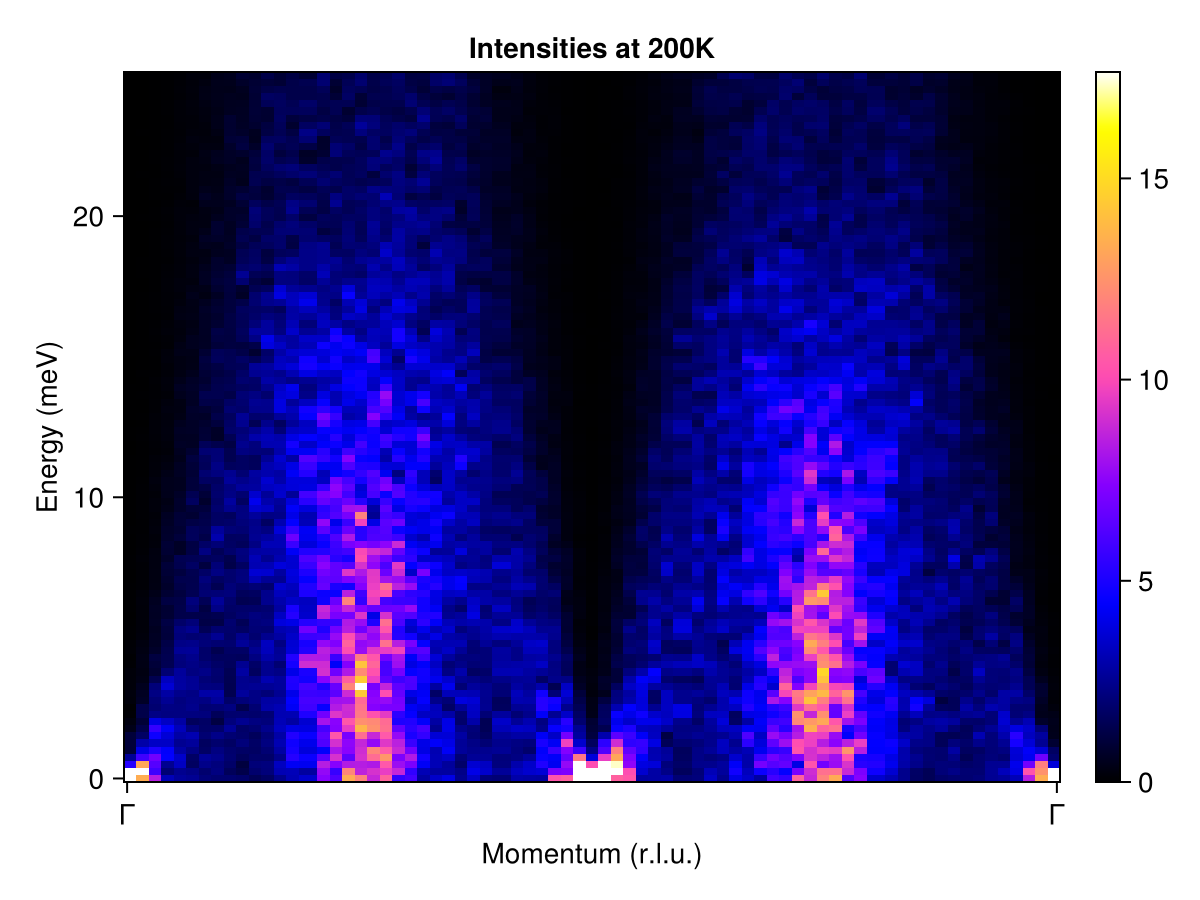

In [106]:
energies = range(0, 25, 100)
dt = 2*langevin.dt
sc = SampledCorrelations(sys; dt, energies, measure)

for _ in 1:10
    for _ in 1:20
        step!(sys, langevin)
    end
    add_sample!(sc, sys)
end

res = intensities(sc, path; energies, langevin.kT)
plot_intensities(res; units, title="Intensities at 200K")